# Joint de novo generation: UV absorption + MOST half-life

Этот notebook реализует минимальный, но воспроизводимый вариант задания с двумя **непересекающимися**
наборами разметки:

- **D_A / MOST:** экспериментальная скорость термической Z→E-изомеризации из официального
  Photoswitch Dataset. Цель — $t_{1/2}=4\ldots24$ h.
- **D_B / UV:** экспериментальный максимум поглощения UVVisML. Цель —
  $\lambda_{max}=300\ldots400$ nm.

SELFIES-GRU генерирует полные молекулы de novo, без scaffold/synthon-шаблона. B0 — sampling
замороженного prior; M1 — joint REINFORCE; ablation — UV-only REINFORCE без expert A и AD_A.
Для каждого метода выполняются три seed с одинаковым числом обращений к reward-моделям.

**Гипотеза:** joint reward увеличит долю молекул, одновременно попадающих в окна A и B по
независимым evaluator-моделям, относительно B0 и UV-only ablation, не разрушив validity,
novelty и diversity.

**Граница вывода:** результаты — только ML-screening. Предсказанный $\lambda_{max}$ не задаёт
силу поглощения; half-life зависит от растворителя и температуры, которые здесь не моделируются.
SA Score и структурные фильтры не доказывают синтезируемость или нетоксичность. Ни один кандидат
не следует использовать без квантово-химической, ретросинтетической и экспериментальной проверки.

## 1. Configuration and reproducibility

Notebook не выполняет `pip install`. Он рассчитан на `.uvgen_venv` репозитория. Все бюджеты,
seeds, версии, SHA-256 входов, split-правила и пути артефактов сохраняются в manifest.
CPU-настройки намеренно компактны. `60×64 + 1200 = 5040` reward evaluations на method/seed.

In [1]:
from __future__ import annotations

import copy
import hashlib
import importlib.metadata as importlib_metadata
import json
import math
import os
import platform
import random
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import selfies as sf
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem, DataStructs, RDConfig, RDLogger, rdBase
from rdkit.Chem import Descriptors, Lipinski, QED, rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset


BASE_SEED = 20260917
RUN_SEEDS = (1701, 1702, 1703)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@dataclass(frozen=True)
class Config:
    m01_local_path: str = "data/raw/M01_photoswitch/dataset/photoswitches.csv"
    m01_url: str = (
        "https://raw.githubusercontent.com/Ryan-Rhys/The-Photoswitch-Dataset/"
        "e30d68287d7803bc0199604e2693ef50b5ee6b3b/dataset/photoswitches.csv"
    )
    m01_expected_sha256: str = "4d18321fea3618acd4d7910f5e2a6e4da20640dfcfc43e939e60a96baf78ed09"
    uv_urls: tuple[str, ...] = (
        "https://raw.githubusercontent.com/learningmatter-mit/uvvisml/"
        "72b2a3ea391f39b8300cefeafd71cae340634740/uvvisml/data/splits/"
        "lambda_max_abs/combined/group_by_smiles/smiles_target_train.csv",
        "https://raw.githubusercontent.com/learningmatter-mit/uvvisml/"
        "72b2a3ea391f39b8300cefeafd71cae340634740/uvvisml/data/splits/"
        "lambda_max_abs/combined/group_by_smiles/smiles_target_val.csv",
        "https://raw.githubusercontent.com/learningmatter-mit/uvvisml/"
        "72b2a3ea391f39b8300cefeafd71cae340634740/uvvisml/data/splits/"
        "lambda_max_abs/combined/group_by_smiles/smiles_target_test.csv",
    )
    a_half_life_low_h: float = 4.0
    a_half_life_high_h: float = 24.0
    b_lambda_low_nm: float = 300.0
    b_lambda_high_nm: float = 400.0
    a_softness_log10_h: float = 0.18
    b_softness_nm: float = 14.0
    fingerprint_bits: int = 2048
    morgan_radius: int = 2
    ensemble_members: int = 3
    trees_per_member: int = 80
    ad_a_threshold: float = 0.20
    ad_b_threshold: float = 0.20
    ad_b_reward_reference_size: int = 1500
    prior_a_target_fraction: float = 0.25
    embedding_dim: int = 128
    hidden_dim: int = 192
    gru_layers: int = 2
    prior_epochs_cpu: int = 3
    prior_epochs_cuda: int = 5
    prior_batch_size: int = 128
    max_selfies_tokens: int = 100
    rl_steps: int = 60
    rl_batch_size: int = 64
    rl_learning_rate: float = 2.0e-4
    kl_weight: float = 0.035
    entropy_weight: float = 0.002
    sampling_temperature: float = 0.95
    final_proposals_per_seed: int = 1200
    sample_batch_size: int = 256
    mw_min: float = 120.0
    mw_max: float = 650.0
    max_rotatable_bonds: int = 14
    max_sa_score: float = 6.0
    min_qed: float = 0.10
    max_abs_formal_charge: int = 1
    max_psoralen_similarity: float = 0.45


CFG = Config()
ROOT = Path.cwd().resolve()
OUTPUT_DIR = ROOT / "outputs" / "uv_most_joint"
MODEL_DIR = OUTPUT_DIR / "models"
CACHE_DIR = ROOT / "data" / "cache" / "uv_most_joint"
for directory in (OUTPUT_DIR, MODEL_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


RDLogger.DisableLog("rdApp.*")
seed_everything(BASE_SEED)
PRIOR_EPOCHS = CFG.prior_epochs_cuda if DEVICE.type == "cuda" else CFG.prior_epochs_cpu
OPTIMIZATION_BUDGET = CFG.rl_steps * CFG.rl_batch_size
TOTAL_EVALUATION_BUDGET = OPTIMIZATION_BUDGET + CFG.final_proposals_per_seed
print(f"root={ROOT}; device={DEVICE}; seeds={RUN_SEEDS}")
print(f"budget/method/seed={OPTIMIZATION_BUDGET}+{CFG.final_proposals_per_seed}={TOTAL_EVALUATION_BUDGET}")

root=/home/sigmatau17/TEST; device=cpu; seeds=(1701, 1702, 1703)
budget/method/seed=3840+1200=5040


## 2. Official sources

M01 читается из локального checkout, а при его отсутствии скачивается с закреплённого commit.
SHA-256 M01 проверяется строго. UVVisML загружается из закреплённого commit; все файлы кешируются,
но content hashes всегда пересчитываются.

In [2]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def download_cached(url: str, destination: Path) -> Path:
    if destination.exists() and destination.stat().st_size > 1000:
        return destination
    temporary = destination.with_suffix(destination.suffix + ".part")
    with requests.get(url, stream=True, timeout=(15, 120)) as response:
        response.raise_for_status()
        with temporary.open("wb") as handle:
            for chunk in response.iter_content(1024 * 1024):
                if chunk:
                    handle.write(chunk)
    if temporary.stat().st_size <= 1000:
        raise RuntimeError(f"Unexpectedly small download: {url}")
    temporary.replace(destination)
    return destination


m01_path = ROOT / CFG.m01_local_path
if not m01_path.exists():
    m01_path = download_cached(CFG.m01_url, CACHE_DIR / "photoswitches.csv")
if sha256_file(m01_path) != CFG.m01_expected_sha256:
    raise RuntimeError("M01 content differs from the pinned official dataset")

uv_paths = {}
for url in CFG.uv_urls:
    filename = url.rsplit("/", 1)[-1]
    preferred = ROOT / "data" / "cache" / "uvvisml" / filename
    uv_paths[filename] = preferred if preferred.exists() else download_cached(url, CACHE_DIR / filename)

SOURCE_HASHES = {"M01_photoswitch": sha256_file(m01_path)}
SOURCE_HASHES.update({name: sha256_file(path) for name, path in uv_paths.items()})
display(pd.Series(SOURCE_HASHES, name="sha256"))

M01_photoswitch            4d18321fea3618acd4d7910f5e2a6e4da20640dfcfc43e...
smiles_target_train.csv    53bbac67b99c52cd6f271de78a141b484ece68e1b64705...
smiles_target_val.csv      e1fb954af3e654d25ac49d1310ec64868186dabd5049bf...
smiles_target_test.csv     9f5141263370ea74dfe10b9691a75ff507abe5abffee47...
Name: sha256, dtype: object

## 3. Canonicalisation and construction of D_A / D_B

Для M01 используется именно формула из задания/презентации:

$$t_{1/2}[h]=\frac{\ln 2}{k_{Z\rightarrow E}[s^{-1}]\,3600},\qquad
y_A=\log_{10}(t_{1/2}[h]).$$

Повторные измерения одной canonical molecule агрегируются медианой. Для UVVisML аналогично
берётся медиана $\lambda_{max}$ по растворителям/источникам. После canonicalisation все молекулы,
встречающиеся в обоих источниках, удаляются из D_B. Assertion ниже гарантирует
$D_A\cap D_B=\varnothing$.

In [3]:
ALLOWED_ATOMIC_NUMBERS = {1, 5, 6, 7, 8, 9, 14, 15, 16, 17, 35, 53}
_uncharger = rdMolStandardize.Uncharger()


def standardize_smiles(value: object) -> str | None:
    if value is None or pd.isna(value):
        return None
    try:
        mol = Chem.MolFromSmiles(str(value), sanitize=True)
        if mol is None:
            return None
        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.FragmentParent(mol)
        mol = _uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        if not mol.GetNumHeavyAtoms():
            return None
        if any(atom.GetAtomicNum() not in ALLOWED_ATOMIC_NUMBERS for atom in mol.GetAtoms()):
            return None
        canonical = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
        # Some highly fused aromatic systems change kekulisation on the first
        # SMILES round-trip.  Store only an idempotent canonical form.
        roundtrip = Chem.MolFromSmiles(canonical, sanitize=True)
        if roundtrip is None:
            return None
        canonical = Chem.MolToSmiles(roundtrip, canonical=True, isomericSmiles=True)
        confirmation = Chem.MolFromSmiles(canonical, sanitize=True)
        if confirmation is None:
            return None
        confirmed = Chem.MolToSmiles(confirmation, canonical=True, isomericSmiles=True)
        return canonical if confirmed == canonical else None
    except Exception:
        return None


m01_raw = pd.read_csv(m01_path, low_memory=False)
rate_column = "rate of thermal isomerisation from Z-E in s-1"
if not {"SMILES", rate_column}.issubset(m01_raw.columns):
    raise KeyError("M01 schema changed")
m01_clean = pd.DataFrame({
    "canonical_smiles": m01_raw["SMILES"].map(standardize_smiles),
    "rate_s_inv": pd.to_numeric(m01_raw[rate_column], errors="coerce"),
    "solvent": m01_raw.get(
        "Solvent used for thermal isomerisation rates", pd.Series("unknown", index=m01_raw.index)
    ).fillna("unknown"),
})
m01_clean = m01_clean.dropna(subset=["canonical_smiles", "rate_s_inv"])
m01_clean = m01_clean[m01_clean["rate_s_inv"] > 0].copy()
m01_clean["half_life_h"] = np.log(2.0) / m01_clean["rate_s_inv"] / 3600.0
m01_clean["log10_half_life_h"] = np.log10(m01_clean["half_life_h"])
D_A = (
    m01_clean.groupby("canonical_smiles", as_index=False)
    .agg(
        log10_half_life_h=("log10_half_life_h", "median"),
        half_life_h=("half_life_h", "median"),
        observation_count=("rate_s_inv", "size"),
        solvent_count=("solvent", "nunique"),
    )
    .sort_values("canonical_smiles")
    .reset_index(drop=True)
)

uv_raw_parts = []
for source_split, filename in (
    ("upstream_train", "smiles_target_train.csv"),
    ("upstream_validation", "smiles_target_val.csv"),
    ("upstream_test", "smiles_target_test.csv"),
):
    part = pd.read_csv(uv_paths[filename], low_memory=False)
    part["source_split"] = source_split
    uv_raw_parts.append(part)
uv_raw = pd.concat(uv_raw_parts, ignore_index=True)
if not {"smiles", "peakwavs_max"}.issubset(uv_raw.columns):
    raise KeyError("UVVisML schema changed")
uv_clean = pd.DataFrame({
    "canonical_smiles": uv_raw["smiles"].map(standardize_smiles),
    "lambda_max_nm": pd.to_numeric(uv_raw["peakwavs_max"], errors="coerce"),
    "solvent": uv_raw.get("solvent", pd.Series("unknown", index=uv_raw.index)).fillna("unknown"),
    "source_split": uv_raw["source_split"],
})
uv_clean = uv_clean.dropna(subset=["canonical_smiles", "lambda_max_nm"])
uv_clean = uv_clean[uv_clean["lambda_max_nm"].between(180.0, 900.0)].copy()
D_B = (
    uv_clean.groupby("canonical_smiles", as_index=False)
    .agg(
        lambda_max_nm=("lambda_max_nm", "median"),
        observation_count=("lambda_max_nm", "size"),
        lambda_within_std_nm=("lambda_max_nm", "std"),
        solvent_count=("solvent", "nunique"),
        source_count=("source_split", "nunique"),
    )
    .fillna({"lambda_within_std_nm": 0.0})
    .sort_values("canonical_smiles")
    .reset_index(drop=True)
)

raw_overlap = set(D_A["canonical_smiles"]) & set(D_B["canonical_smiles"])
D_B = D_B[~D_B["canonical_smiles"].isin(raw_overlap)].reset_index(drop=True)
assert set(D_A["canonical_smiles"]).isdisjoint(D_B["canonical_smiles"])
print(f"D_A={len(D_A):,}; D_B={len(D_B):,}; removed overlap from D_B={len(raw_overlap):,}")
display(D_A.describe(include="all"))

D_A=75; D_B=14,806; removed overlap from D_B=0


,canonical_smiles,log10_half_life_h,half_life_h,observation_count,solvent_count
count,75,75.000000,75.000000,75.0,75.0
unique,75,NaN,NaN,NaN,NaN
top,C=Cc1ccc2c(c1)/N=N\c1cc(C=C)ccc1CC2,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,0.774738,6142.735614,1.0,1.0
std,NaN,1.831874,46385.014847,0.0,0.0
min,NaN,-3.231351,0.000587,1.0,1.0
25%,NaN,-0.900919,0.125820,1.0,1.0
50%,NaN,1.117271,13.099998,1.0,1.0
75%,NaN,1.981894,95.999963,1.0,1.0


## 4. Separate deterministic Murcko scaffold splits

Каждый expert получает собственный train/validation/test split. Один Murcko scaffold никогда не
попадает в несколько частей одного набора. Исходные upstream UVVisML splits не переиспользуются:
после агрегации и overlap removal создаётся единообразный deterministic split для обоих experts.

In [4]:
def scaffold_key(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return scaffold or smiles


def add_scaffold_split(frame: pd.DataFrame, seed: int) -> pd.DataFrame:
    result = frame.copy()
    result["scaffold"] = result["canonical_smiles"].map(scaffold_key)
    if len(result) < 200:
        # A random group split can put a single large analogue series into the
        # whole calibration set.  Balance both molecule counts and scaffold
        # counts; the three largest groups seed train/calibration/test.
        labels = np.empty(len(result), dtype=object)
        groups = [(scaffold, list(indices)) for scaffold, indices in result.groupby("scaffold").groups.items()]
        groups.sort(
            key=lambda item: (
                -len(item[1]),
                hashlib.sha256(f"{seed}|{item[0]}".encode()).hexdigest(),
            )
        )
        split_names = ("train", "validation", "test")
        target_rows = np.asarray((0.65, 0.175, 0.175)) * len(result)
        target_groups = np.asarray((0.60, 0.20, 0.20)) * len(groups)
        row_counts = np.zeros(3, dtype=float)
        group_counts = np.zeros(3, dtype=float)
        for group_index, (_, group_indices) in enumerate(groups):
            if group_index < 3:
                chosen = group_index
            else:
                costs = []
                for split_index in range(3):
                    proposed_rows = row_counts.copy()
                    proposed_groups = group_counts.copy()
                    proposed_rows[split_index] += len(group_indices)
                    proposed_groups[split_index] += 1
                    row_cost = np.sum(((proposed_rows - target_rows) / np.maximum(target_rows, 1.0)) ** 2)
                    group_cost = np.sum(((proposed_groups - target_groups) / np.maximum(target_groups, 1.0)) ** 2)
                    costs.append(float(row_cost + group_cost))
                chosen = int(np.argmin(costs))
            labels[group_indices] = split_names[chosen]
            row_counts[chosen] += len(group_indices)
            group_counts[chosen] += 1
    else:
        indices = np.arange(len(result))
        outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
        train_indices, holdout_indices = next(outer.split(indices, groups=result["scaffold"]))
        inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed + 1)
        val_relative, test_relative = next(
            inner.split(holdout_indices, groups=result.iloc[holdout_indices]["scaffold"])
        )
        labels = np.full(len(result), "train", dtype=object)
        labels[holdout_indices[val_relative]] = "validation"
        labels[holdout_indices[test_relative]] = "test"
    result["split"] = labels
    assert result.groupby("scaffold")["split"].nunique().max() == 1
    assert set(result["split"]) == {"train", "validation", "test"}
    return result


D_A = add_scaffold_split(D_A, BASE_SEED + 11)
D_B = add_scaffold_split(D_B, BASE_SEED + 22)
D_A.assign(dataset="D_A").to_csv(OUTPUT_DIR / "dataset_A_curated.csv", index=False)
D_B.assign(dataset="D_B").to_csv(OUTPUT_DIR / "dataset_B_curated.csv", index=False)
split_summary = pd.concat([
    D_A.groupby("split").agg(molecules=("canonical_smiles", "size"), scaffolds=("scaffold", "nunique")).assign(dataset="D_A"),
    D_B.groupby("split").agg(molecules=("canonical_smiles", "size"), scaffolds=("scaffold", "nunique")).assign(dataset="D_B"),
]).reset_index()
display(split_summary[["dataset", "split", "molecules", "scaffolds"]])

,dataset,split,molecules,scaffolds
0,D_A,test,15,3
1,D_A,train,44,9
2,D_A,validation,16,3
3,D_B,test,1410,742
4,D_B,train,11894,5933
5,D_B,validation,1502,742


## 5. Fingerprints, independent model families, and uncertainty

Reward experts — ensembles of `RandomForestRegressor`. Final evaluators — separately seeded
ensembles of `ExtraTreesRegressor`; они не участвуют в RL reward. Для каждого expert/model-role
90% split-conformal radius вычисляется **только на validation**. Отчётная uncertainty — максимум
ensemble disagreement и `q90/1.645`. Test используется только для итоговой оценки.

In [5]:
FP_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(
    radius=CFG.morgan_radius, fpSize=CFG.fingerprint_bits
)


def bit_fingerprint(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(smiles)
    return FP_GENERATOR.GetFingerprint(mol)


def fingerprint_matrix(smiles_values) -> np.ndarray:
    matrix = np.zeros((len(smiles_values), CFG.fingerprint_bits), dtype=np.uint8)
    for row_index, smiles in enumerate(smiles_values):
        DataStructs.ConvertToNumpyArray(bit_fingerprint(smiles), matrix[row_index])
    return matrix


def train_ensemble(frame, target, estimator_kind, seed_offset):
    X = fingerprint_matrix(frame["canonical_smiles"].tolist())
    y = frame[target].to_numpy(dtype=np.float32)
    masks = {name: frame["split"].eq(name).to_numpy() for name in ("train", "validation", "test")}
    models = []
    for member in range(CFG.ensemble_members):
        common = dict(
            n_estimators=CFG.trees_per_member,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=BASE_SEED + seed_offset + member,
        )
        if estimator_kind == "random_forest":
            model = RandomForestRegressor(bootstrap=True, **common)
        elif estimator_kind == "extra_trees":
            model = ExtraTreesRegressor(bootstrap=False, **common)
        else:
            raise ValueError(estimator_kind)
        model.fit(X[masks["train"]], y[masks["train"]])
        models.append(model)

    def raw_predict(matrix):
        members = np.stack([model.predict(matrix) for model in models], axis=0)
        return members.mean(axis=0), members.std(axis=0, ddof=0)

    val_mean, _ = raw_predict(X[masks["validation"]])
    q90 = float(np.quantile(np.abs(y[masks["validation"]] - val_mean), 0.90, method="higher"))
    return {"models": models, "q90": q90, "X": X, "y": y, "masks": masks, "kind": estimator_kind}


def bundle_predict(bundle, matrix):
    members = np.stack([model.predict(matrix) for model in bundle["models"]], axis=0)
    mean = members.mean(axis=0)
    ensemble_std = members.std(axis=0, ddof=0)
    return mean, np.maximum(ensemble_std, bundle["q90"] / 1.645)


def bundle_metrics(bundle, expert, role, unit):
    rows = []
    for split_name in ("validation", "test"):
        mask = bundle["masks"][split_name]
        mean, uncertainty = bundle_predict(bundle, bundle["X"][mask])
        truth = bundle["y"][mask]
        rows.append({
            "expert": expert,
            "model_role": role,
            "estimator": bundle["kind"],
            "split": split_name,
            "n": int(mask.sum()),
            "unit": unit,
            "mae": float(mean_absolute_error(truth, mean)),
            "rmse": float(mean_squared_error(truth, mean) ** 0.5),
            "r2": float(r2_score(truth, mean)),
            "conformal_q90": bundle["q90"],
            "mean_uncertainty": float(uncertainty.mean()),
            "q90_coverage": float(np.mean(np.abs(truth - mean) <= bundle["q90"])),
        })
    return rows

In [6]:
reward_A = train_ensemble(D_A, "log10_half_life_h", "random_forest", 1000)
reward_B = train_ensemble(D_B, "lambda_max_nm", "random_forest", 2000)
evaluator_A = train_ensemble(D_A, "log10_half_life_h", "extra_trees", 3000)
evaluator_B = train_ensemble(D_B, "lambda_max_nm", "extra_trees", 4000)

reviewer_metric_rows = []
reviewer_metric_rows += bundle_metrics(reward_A, "A_half_life", "reward", "log10(hours)")
reviewer_metric_rows += bundle_metrics(reward_B, "B_lambda_max", "reward", "nm")
reviewer_metric_rows += bundle_metrics(evaluator_A, "A_half_life", "independent_evaluator", "log10(hours)")
reviewer_metric_rows += bundle_metrics(evaluator_B, "B_lambda_max", "independent_evaluator", "nm")
reviewer_metrics = pd.DataFrame(reviewer_metric_rows)
reviewer_metrics.to_csv(OUTPUT_DIR / "reviewer_metrics.csv", index=False)
display(reviewer_metrics)

for name, bundle in {
    "reward_A_rf": reward_A,
    "reward_B_rf": reward_B,
    "evaluator_A_extra_trees": evaluator_A,
    "evaluator_B_extra_trees": evaluator_B,
}.items():
    joblib.dump(
        {"models": bundle["models"], "conformal_q90": bundle["q90"], "config": asdict(CFG)},
        MODEL_DIR / f"{name}.joblib",
    )

,expert,model_role,estimator,split,n,unit,mae,rmse,r2,conformal_q90,mean_uncertainty,q90_coverage
0,A_half_life,reward,random_forest,validation,16,log10(hours),0.534287,0.734268,-0.238660,1.418820,0.862504,0.937500
1,A_half_life,reward,random_forest,test,15,log10(hours),0.334866,0.620692,-0.067706,1.418820,0.862504,0.933333
2,B_lambda_max,reward,random_forest,validation,1502,nm,44.547581,61.860986,0.717170,101.131817,61.478308,0.900133
3,B_lambda_max,reward,random_forest,test,1410,nm,38.473499,56.599929,0.683366,101.131817,61.478308,0.934752
4,A_half_life,independent_evaluator,extra_trees,validation,16,log10(hours),0.450054,0.624912,0.102818,1.081400,0.657386,0.937500
5,A_half_life,independent_evaluator,extra_trees,test,15,log10(hours),0.411621,0.554159,0.148924,1.081400,0.657386,0.933333
6,B_lambda_max,independent_evaluator,extra_trees,validation,1502,nm,41.648914,58.642270,0.745837,98.335528,59.778436,0.900133
7,B_lambda_max,independent_evaluator,extra_trees,test,1410,nm,36.166974,54.368022,0.707846,98.335528,59.778436,0.936879


## 6. Safety and synthesizability triage

Hard filter требует RDKit-valid single-component molecule, допустимые элементы/MW/charge,
отсутствие radicals, PAINS, выбранных реакционноспособных групп и явного psoralen/angelicin core.
Кроме substructure veto действует строгое условие Tanimoto similarity к известным псораленам
`< 0.45`. Используется SA Score `<=6`. Blanket BRENK **не используется**, поскольку он
необоснованно отбрасывает azo photoswitches, необходимые D_A.

In [7]:
contrib_sa_path = Path(RDConfig.RDContribDir) / "SA_Score"
if str(contrib_sa_path) not in sys.path:
    sys.path.insert(0, str(contrib_sa_path))
import sascorer

catalog_params = FilterCatalogParams()
for catalog in (
    FilterCatalogParams.FilterCatalogs.PAINS_A,
    FilterCatalogParams.FilterCatalogs.PAINS_B,
    FilterCatalogParams.FilterCatalogs.PAINS_C,
):
    catalog_params.AddCatalog(catalog)
PAINS_CATALOG = FilterCatalog(catalog_params)

FUROCOUMARIN_SMILES = {
    "psoralen_core": "C1=CC(=O)OC2=CC3=C(C=CO3)C=C21",
    "angelicin_core": "C1=CC2=C(C=CO2)C3=C1C=CC(=O)O3",
}
FUROCOUMARIN_QUERIES = {name: Chem.MolFromSmiles(value) for name, value in FUROCOUMARIN_SMILES.items()}
assert all(query is not None for query in FUROCOUMARIN_QUERIES.values())
KNOWN_PSORALENS = (
    "C1=CC(=O)OC2=CC3=C(C=CO3)C=C21",  # psoralen
    "C1=CC2=C(C=CO2)C3=C1C=CC(=O)O3",  # angelicin
    "COC1=C2C=CC(=O)OC2=CC3=C1C=CO3",  # methoxsalen-like
    "CC1=C2C=COC2=CC2=C1OC(=O)C=C2",   # methyl furocoumarin
)
KNOWN_PSORALEN_FPS = [bit_fingerprint(Chem.MolToSmiles(Chem.MolFromSmiles(s))) for s in KNOWN_PSORALENS]

REACTIVE_SMARTS = {
    "acyl_halide": "[CX3](=[OX1])[F,Cl,Br,I]",
    "sulfonyl_halide": "[SX4](=[OX1])(=[OX1])[F,Cl,Br,I]",
    "isocyanate": "[NX2]=[CX2]=[OX1]",
    "isothiocyanate": "[NX2]=[CX2]=[SX1]",
    "organic_peroxide": "[OX2]-[OX2]",
    "diazonium": "[N+]#N",
}
REACTIVE_QUERIES = {name: Chem.MolFromSmarts(smarts) for name, smarts in REACTIVE_SMARTS.items()}
assert all(query is not None for query in REACTIVE_QUERIES.values())


def hard_filter(smiles: str) -> dict:
    result = {
        "input_smiles": smiles,
        "canonical_smiles": None,
        "rdkit_valid": False,
        "passes_hard_filters": False,
        "filter_reason": "invalid_smiles",
        "molecular_weight": np.nan,
        "sa_score": np.nan,
        "qed": np.nan,
        "rotatable_bonds": np.nan,
        "psoralen_similarity": np.nan,
    }
    try:
        raw_mol = Chem.MolFromSmiles(str(smiles), sanitize=True)
    except Exception:
        raw_mol = None
    if raw_mol is None:
        return result
    result["rdkit_valid"] = True
    if len(Chem.GetMolFrags(raw_mol)) != 1:
        result["filter_reason"] = "multiple_fragments"
        return result
    canonical = standardize_smiles(smiles)
    if canonical is None:
        result["filter_reason"] = "standardization_failed"
        return result
    mol = Chem.MolFromSmiles(canonical)
    result["canonical_smiles"] = canonical
    result["molecular_weight"] = float(Descriptors.MolWt(mol))
    result["sa_score"] = float(sascorer.calculateScore(mol))
    result["qed"] = float(QED.qed(mol))
    result["rotatable_bonds"] = int(Lipinski.NumRotatableBonds(mol))
    fp = bit_fingerprint(canonical)
    result["psoralen_similarity"] = float(max(DataStructs.BulkTanimotoSimilarity(fp, KNOWN_PSORALEN_FPS)))

    checks = (
        (mol.GetNumHeavyAtoms() < 8, "too_few_heavy_atoms"),
        (mol.GetNumHeavyAtoms() > 55, "too_many_heavy_atoms"),
        (not CFG.mw_min <= result["molecular_weight"] <= CFG.mw_max, "molecular_weight"),
        (result["rotatable_bonds"] > CFG.max_rotatable_bonds, "too_many_rotatable_bonds"),
        (result["sa_score"] > CFG.max_sa_score, "synthetic_accessibility"),
        (result["qed"] < CFG.min_qed, "very_low_qed"),
        (abs(Chem.GetFormalCharge(mol)) > CFG.max_abs_formal_charge, "formal_charge"),
        (any(atom.GetNumRadicalElectrons() for atom in mol.GetAtoms()), "radical"),
        (any(atom.GetAtomicNum() not in ALLOWED_ATOMIC_NUMBERS for atom in mol.GetAtoms()), "disallowed_element"),
    )
    for failed, reason in checks:
        if failed:
            result["filter_reason"] = reason
            return result
    for name, query in FUROCOUMARIN_QUERIES.items():
        if mol.HasSubstructMatch(query):
            result["filter_reason"] = name
            return result
    if result["psoralen_similarity"] >= CFG.max_psoralen_similarity:
        result["filter_reason"] = "psoralen_similarity"
        return result
    pains = PAINS_CATALOG.GetFirstMatch(mol)
    if pains is not None:
        result["filter_reason"] = f"PAINS:{pains.GetDescription()}"
        return result
    for name, query in REACTIVE_QUERIES.items():
        if mol.HasSubstructMatch(query):
            result["filter_reason"] = f"reactive:{name}"
            return result
    result["passes_hard_filters"] = True
    result["filter_reason"] = "ok"
    return result

## 7. Reward and applicability domains

Для M1 reward является геометрическим средним гладких A/B window scores, uncertainty penalties,
AD_A/AD_B, SA и QED. UV-only ablation полностью удаляет A и AD_A. Hard-filter failures и
молекулы из D_A∪D_B получают ноль. Applicability distance — `1 − max Tanimoto` к train set;
для быстрого RL D_B reference детерминированно ограничен, но в финальном CSV расстояния
пересчитываются к **полному** D_A и D_B.

In [8]:
KNOWN_A = frozenset(D_A["canonical_smiles"])
KNOWN_B = frozenset(D_B["canonical_smiles"])
KNOWN_UNION = KNOWN_A | KNOWN_B
A_TRAIN_SMILES = D_A.loc[D_A["split"].eq("train"), "canonical_smiles"].tolist()
B_TRAIN_SMILES = D_B.loc[D_B["split"].eq("train"), "canonical_smiles"].tolist()
A_REWARD_REFERENCE_FPS = [bit_fingerprint(s) for s in A_TRAIN_SMILES]
B_REWARD_REFERENCE_SMILES = sorted(
    B_TRAIN_SMILES,
    key=lambda s: hashlib.sha256(("ad_b|" + s).encode()).hexdigest(),
)[: CFG.ad_b_reward_reference_size]
B_REWARD_REFERENCE_FPS = [bit_fingerprint(s) for s in B_REWARD_REFERENCE_SMILES]
B_TRAIN_FULL_FPS = [bit_fingerprint(s) for s in B_TRAIN_SMILES]
ALL_A_FPS = [bit_fingerprint(s) for s in D_A["canonical_smiles"]]
ALL_B_FPS = [bit_fingerprint(s) for s in D_B["canonical_smiles"]]
A_LOW, A_HIGH = np.log10(CFG.a_half_life_low_h), np.log10(CFG.a_half_life_high_h)


def sigmoid(value):
    return 1.0 / (1.0 + np.exp(-np.clip(value, -50.0, 50.0)))


def interval_score(mean, uncertainty, low, high, softness):
    conservative_low = mean - uncertainty
    conservative_high = mean + uncertainty
    return sigmoid((conservative_low - low) / softness) * sigmoid((high - conservative_high) / softness)


def score_reward_batch(smiles_values: list[str], objective: str) -> pd.DataFrame:
    if objective not in {"joint", "uv_only"}:
        raise ValueError(objective)
    rows = [hard_filter(smiles) for smiles in smiles_values]
    eligible_positions, eligible_smiles = [], []
    seen = set()
    for position, row in enumerate(rows):
        canonical = row["canonical_smiles"]
        row["novel_vs_D_A_D_B"] = bool(canonical and canonical not in KNOWN_UNION)
        row["duplicate_in_batch"] = bool(canonical and canonical in seen)
        if canonical:
            seen.add(canonical)
        if row["passes_hard_filters"] and row["novel_vs_D_A_D_B"]:
            eligible_positions.append(position)
            eligible_smiles.append(canonical)

    if eligible_smiles:
        matrix = fingerprint_matrix(eligible_smiles)
        pred_a, unc_a = bundle_predict(reward_A, matrix)
        pred_b, unc_b = bundle_predict(reward_B, matrix)
    else:
        pred_a = unc_a = pred_b = unc_b = np.array([], dtype=float)

    for position, canonical, pa, ua, pb, ub in zip(
        eligible_positions, eligible_smiles, pred_a, unc_a, pred_b, unc_b
    ):
        row = rows[position]
        fp = bit_fingerprint(canonical)
        sim_a = max(DataStructs.BulkTanimotoSimilarity(fp, A_REWARD_REFERENCE_FPS), default=0.0)
        sim_b = max(DataStructs.BulkTanimotoSimilarity(fp, B_REWARD_REFERENCE_FPS), default=0.0)
        score_a = float(interval_score(pa, ua, A_LOW, A_HIGH, CFG.a_softness_log10_h))
        score_b = float(interval_score(pb, ub, CFG.b_lambda_low_nm, CFG.b_lambda_high_nm, CFG.b_softness_nm))
        uncertainty_a_score = math.exp(-float(ua) / 1.2)
        uncertainty_b_score = math.exp(-float(ub) / 70.0)
        ad_a_score = 0.20 + 0.80 * float(sigmoid((sim_a - CFG.ad_a_threshold) / 0.07))
        ad_b_score = 0.20 + 0.80 * float(sigmoid((sim_b - CFG.ad_b_threshold) / 0.07))
        sa_score = math.exp(-0.30 * max(0.0, float(row["sa_score"]) - 3.0))
        qed_score = 0.50 + 0.50 * float(row["qed"])
        components = [score_b, uncertainty_b_score, ad_b_score, sa_score, qed_score]
        if objective == "joint":
            components.extend([score_a, uncertainty_a_score, ad_a_score])
        reward_value = float(np.prod(np.clip(components, 1.0e-12, 1.0)) ** (1.0 / len(components)))
        if row["duplicate_in_batch"]:
            reward_value *= 0.20
        row.update({
            "reward_pred_A_log10_half_life_h": float(pa),
            "reward_uncertainty_A_log10_h": float(ua),
            "reward_pred_B_lambda_max_nm": float(pb),
            "reward_uncertainty_B_nm": float(ub),
            "reward_distance_to_D_A_train": float(1.0 - sim_a),
            "reward_distance_to_D_B_train": float(1.0 - sim_b),
            "reward_A_window_score": score_a,
            "reward_B_window_score": score_b,
            "reward": reward_value,
        })

    defaults = {
        "reward_pred_A_log10_half_life_h": np.nan,
        "reward_uncertainty_A_log10_h": np.nan,
        "reward_pred_B_lambda_max_nm": np.nan,
        "reward_uncertainty_B_nm": np.nan,
        "reward_distance_to_D_A_train": np.nan,
        "reward_distance_to_D_B_train": np.nan,
        "reward_A_window_score": 0.0,
        "reward_B_window_score": 0.0,
        "reward": 0.0,
    }
    for row in rows:
        for key, value in defaults.items():
            row.setdefault(key, value)
    return pd.DataFrame(rows)

## 8. Balanced SELFIES prior corpus

Prior обучается с нуля на union **только train** structures D_A и D_B. Из-за размера D_A его
train structures детерминированно повторяются так, чтобы составлять примерно 25% prior corpus.
Это не дублирует labels в expert A и не переносит val/test в генератор; это лишь предотвращает
исчезновение photoswitch chemistry на фоне большого D_B.

In [9]:
def to_selfies_record(smiles):
    try:
        tokens = list(sf.split_selfies(sf.encoder(smiles)))
    except Exception:
        return None
    if not 1 <= len(tokens) <= CFG.max_selfies_tokens:
        return None
    return smiles, tokens


a_records = [record for s in A_TRAIN_SMILES if (record := to_selfies_record(s)) is not None]
b_records = [record for s in B_TRAIN_SMILES if (record := to_selfies_record(s)) is not None]
desired_a_rows = math.ceil(len(b_records) * CFG.prior_a_target_fraction / (1.0 - CFG.prior_a_target_fraction))
A_REPEAT_FACTOR = max(1, math.ceil(desired_a_rows / max(len(a_records), 1)))
prior_records = (a_records * A_REPEAT_FACTOR) + b_records
prior_records = sorted(
    prior_records,
    key=lambda item: hashlib.sha256((item[0] + "|prior").encode()).hexdigest(),
)
pd.DataFrame({
    "canonical_smiles": [s for s, _ in prior_records],
    "source": ["D_A_train"] * (len(a_records) * A_REPEAT_FACTOR) + ["D_B_train"] * len(b_records),
})  # source order is recorded more accurately below

SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>"]
vocabulary = SPECIAL_TOKENS + sorted({token for _, tokens in prior_records for token in tokens})
token_to_id = {token: index for index, token in enumerate(vocabulary)}
id_to_token = {index: token for token, index in token_to_id.items()}
PAD_ID, BOS_ID, EOS_ID = (token_to_id[token] for token in SPECIAL_TOKENS)


class SelfiesDataset(Dataset):
    def __init__(self, records):
        self.sequences = [
            torch.tensor([BOS_ID] + [token_to_id[t] for t in tokens] + [EOS_ID], dtype=torch.long)
            for _, tokens in records
        ]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index]


def collate_sequences(items):
    return pad_sequence(items, batch_first=True, padding_value=PAD_ID)


prior_corpus_a = pd.DataFrame(a_records * A_REPEAT_FACTOR, columns=["canonical_smiles", "tokens"]).assign(source="D_A_train")
prior_corpus_b = pd.DataFrame(b_records, columns=["canonical_smiles", "tokens"]).assign(source="D_B_train")
prior_corpus = pd.concat([prior_corpus_a, prior_corpus_b], ignore_index=True)
prior_corpus.drop(columns="tokens").to_csv(OUTPUT_DIR / "prior_training_corpus.csv", index=False)
prior_dataset = SelfiesDataset(prior_records)
loader_generator = torch.Generator().manual_seed(BASE_SEED)
prior_loader = DataLoader(
    prior_dataset, batch_size=CFG.prior_batch_size, shuffle=True, generator=loader_generator,
    num_workers=0, collate_fn=collate_sequences,
)
print(f"A train={len(a_records)} repeated ×{A_REPEAT_FACTOR}; B train={len(b_records)}; corpus={len(prior_dataset)}")

A train=44 repeated ×74; B train=9722; corpus=12978


In [10]:
class SelfiesGRU(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG.embedding_dim, padding_idx=PAD_ID)
        self.gru = nn.GRU(
            CFG.embedding_dim, CFG.hidden_dim, num_layers=CFG.gru_layers, batch_first=True,
            dropout=0.10 if CFG.gru_layers > 1 else 0.0,
        )
        self.output = nn.Linear(CFG.hidden_dim, vocab_size)

    def forward(self, token_ids, hidden=None):
        states, hidden = self.gru(self.embedding(token_ids), hidden)
        return self.output(states), hidden


prior = SelfiesGRU(len(vocabulary)).to(DEVICE)
optimizer = torch.optim.AdamW(prior.parameters(), lr=1.0e-3, weight_decay=1.0e-5)
prior_history = []
for epoch in range(1, PRIOR_EPOCHS + 1):
    prior.train()
    epoch_loss, token_count = 0.0, 0
    for sequences in prior_loader:
        sequences = sequences.to(DEVICE)
        logits, _ = prior(sequences[:, :-1])
        targets = sequences[:, 1:]
        loss_sum = F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]), targets.reshape(-1),
            ignore_index=PAD_ID, reduction="sum",
        )
        count = int(targets.ne(PAD_ID).sum())
        loss = loss_sum / max(count, 1)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(prior.parameters(), 2.0)
        optimizer.step()
        epoch_loss += float(loss_sum.detach())
        token_count += count
    mean_loss = epoch_loss / max(token_count, 1)
    prior_history.append({"epoch": epoch, "cross_entropy": mean_loss, "perplexity": math.exp(mean_loss)})
    print(f"epoch={epoch}/{PRIOR_EPOCHS} CE={mean_loss:.4f} PPL={math.exp(mean_loss):.2f}")

pd.DataFrame(prior_history).to_csv(OUTPUT_DIR / "prior_training_history.csv", index=False)
torch.save({
    "state_dict": {key: value.detach().cpu() for key, value in prior.state_dict().items()},
    "vocabulary": vocabulary, "config": asdict(CFG), "seed": BASE_SEED,
}, MODEL_DIR / "selfies_prior.pt")

epoch=1/3 CE=2.0917 PPL=8.10


epoch=2/3 CE=1.3613 PPL=3.90


epoch=3/3 CE=1.1112 PPL=3.04


## 9. Sampling and REINFORCE

Каждый M1/ablation run начинает с одной и той же frozen prior checkpoint, но получает отдельный
run seed и отдельный optimizer. Exact categorical KL удерживает policy около prior; entropy bonus
снижает collapse. Повторно встречавшаяся молекула штрафуется, но не скрывается из audit.

In [11]:
@torch.no_grad()
def sample_token_sequences(model, count, temperature):
    model.eval()
    current = torch.full((count, 1), BOS_ID, dtype=torch.long, device=DEVICE)
    hidden = None
    finished = torch.zeros(count, dtype=torch.bool, device=DEVICE)
    sequences = [[BOS_ID] for _ in range(count)]
    for _ in range(CFG.max_selfies_tokens + 1):
        logits, hidden = model(current, hidden)
        next_logits = logits[:, -1, :] / temperature
        next_logits[:, PAD_ID] = -torch.inf
        next_logits[:, BOS_ID] = -torch.inf
        next_ids = torch.multinomial(torch.softmax(next_logits, dim=-1), 1).squeeze(1)
        next_ids = torch.where(finished, torch.full_like(next_ids, EOS_ID), next_ids)
        for row, token_id in enumerate(next_ids.tolist()):
            if not finished[row]:
                sequences[row].append(token_id)
        finished |= next_ids.eq(EOS_ID)
        current = next_ids[:, None]
        if bool(finished.all()):
            break
    smiles_values = []
    for sequence in sequences:
        content = []
        for token_id in sequence[1:]:
            if token_id == EOS_ID:
                break
            if token_id not in (PAD_ID, BOS_ID):
                content.append(id_to_token[token_id])
        try:
            smiles_values.append(sf.decoder("".join(content)) if content else "")
        except Exception:
            smiles_values.append("")
    return smiles_values, sequences


def sequence_policy_terms(agent, frozen_prior, sampled_sequences):
    tensors = [torch.tensor(sequence, dtype=torch.long) for sequence in sampled_sequences]
    padded = pad_sequence(tensors, batch_first=True, padding_value=PAD_ID).to(DEVICE)
    inputs, targets = padded[:, :-1], padded[:, 1:]
    mask = targets.ne(PAD_ID)
    lengths = mask.sum(dim=1).clamp_min(1)
    agent_logits, _ = agent(inputs)
    with torch.no_grad():
        prior_logits, _ = frozen_prior(inputs)
    agent_logits = agent_logits.clone()
    prior_logits = prior_logits.clone()
    for token_id in (PAD_ID, BOS_ID):
        agent_logits[..., token_id] = -1.0e9
        prior_logits[..., token_id] = -1.0e9
    agent_logp = F.log_softmax(agent_logits, dim=-1)
    prior_logp = F.log_softmax(prior_logits, dim=-1)
    agent_p = agent_logp.exp()
    selected = agent_logp.gather(-1, targets[..., None]).squeeze(-1)
    mean_logp = (selected * mask).sum(1) / lengths
    mean_kl = ((agent_p * (agent_logp - prior_logp)).sum(-1) * mask).sum(1) / lengths
    entropy = (-(agent_p * agent_logp).sum(-1) * mask).sum(1) / lengths
    return mean_logp, mean_kl, entropy

In [12]:
for parameter in prior.parameters():
    parameter.requires_grad_(False)
prior.eval()


def train_rl_run(method_id: str, seed: int):
    objective = "joint" if method_id == "M1_joint_rl" else "uv_only"
    seed_everything(seed)
    agent = copy.deepcopy(prior).to(DEVICE)
    for parameter in agent.parameters():
        parameter.requires_grad_(True)
    agent_optimizer = torch.optim.Adam(agent.parameters(), lr=CFG.rl_learning_rate)
    archive = set()
    history, audit_parts = [], []
    for step in range(1, CFG.rl_steps + 1):
        smiles, sequences = sample_token_sequences(agent, CFG.rl_batch_size, CFG.sampling_temperature)
        scored = score_reward_batch(smiles, objective)
        scored["method_id"], scored["seed"], scored["phase"], scored["step"] = method_id, seed, "optimization", step
        rewards_np = scored["reward"].to_numpy(np.float32)
        for row_index, canonical in enumerate(scored["canonical_smiles"]):
            if canonical and canonical in archive:
                rewards_np[row_index] *= 0.20
            if canonical and rewards_np[row_index] > 0:
                archive.add(canonical)
        rewards = torch.tensor(rewards_np, dtype=torch.float32, device=DEVICE)
        mean_logp, mean_kl, entropy = sequence_policy_terms(agent, prior, sequences)
        advantage = (rewards - rewards.mean()) / (rewards.std(unbiased=False) + 1.0e-6)
        loss = -(advantage.detach() * mean_logp).mean()
        loss = loss + CFG.kl_weight * mean_kl.mean() - CFG.entropy_weight * entropy.mean()
        agent_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), 1.0)
        agent_optimizer.step()
        history.append({
            "method_id": method_id, "seed": seed, "step": step,
            "mean_reward": float(rewards.mean()), "max_reward": float(rewards.max()),
            "hard_filter_fraction": float(scored["passes_hard_filters"].mean()),
            "mean_kl": float(mean_kl.mean().detach()), "mean_entropy": float(entropy.mean().detach()),
            "archive_size": len(archive),
        })
        audit_parts.append(scored)
        if step == 1 or step % 20 == 0 or step == CFG.rl_steps:
            print(method_id, seed, step, f"reward={float(rewards.mean()):.4f}", f"archive={len(archive)}")
    torch.save({
        "state_dict": {key: value.detach().cpu() for key, value in agent.state_dict().items()},
        "vocabulary": vocabulary, "config": asdict(CFG), "method_id": method_id, "seed": seed,
    }, MODEL_DIR / f"agent_{method_id}_seed{seed}.pt")
    return agent, pd.DataFrame(history), pd.concat(audit_parts, ignore_index=True)


def evaluate_b0_optimization_budget(seed: int):
    seed_everything(seed)
    parts, remaining, step = [], OPTIMIZATION_BUDGET, 0
    while remaining:
        count = min(CFG.rl_batch_size, remaining)
        smiles, _ = sample_token_sequences(prior, count, CFG.sampling_temperature)
        scored = score_reward_batch(smiles, "joint")
        step += 1
        scored["method_id"], scored["seed"], scored["phase"], scored["step"] = "B0_prior_random", seed, "optimization", step
        parts.append(scored)
        remaining -= count
    return pd.concat(parts, ignore_index=True)

## 10. Three independent runs per strategy

B0 также расходует и логирует ровно 3840 optimization-budget predictions per seed, хотя policy
не обновляется. Это позволяет честно сравнивать методы при одинаковом maximum number of evaluated
molecules. Затем у каждого метода/seed берётся независимая фиксированная quota из 1200 final
proposals — без адаптивной досэмплировки и без ручного cherry-picking.

In [13]:
agents = {}
optimization_audits = []
rl_histories = []
for run_seed in RUN_SEEDS:
    optimization_audits.append(evaluate_b0_optimization_budget(run_seed))
    for method in ("M1_joint_rl", "A1_uv_only_rl"):
        trained_agent, history, audit = train_rl_run(method, run_seed)
        agents[(method, run_seed)] = trained_agent
        rl_histories.append(history)
        optimization_audits.append(audit)

rl_history = pd.concat(rl_histories, ignore_index=True)
optimization_audit = pd.concat(optimization_audits, ignore_index=True)
rl_history.to_csv(OUTPUT_DIR / "rl_training_histories.csv", index=False)
assert optimization_audit.groupby(["method_id", "seed"]).size().eq(OPTIMIZATION_BUDGET).all()
print(f"optimization audit rows={len(optimization_audit):,}")

M1_joint_rl 1701 1 reward=0.0804 archive=36


M1_joint_rl 1701 20 reward=0.1397 archive=901


M1_joint_rl 1701 40 reward=0.1558 archive=1970


M1_joint_rl 1701 60 reward=0.1464 archive=3016


A1_uv_only_rl 1701 1 reward=0.1056 archive=36


...

M1_joint_rl 1703 60 reward=0.1874 archive=3086


A1_uv_only_rl 1703 1 reward=0.0676 archive=24


A1_uv_only_rl 1703 20 reward=0.2027 archive=857


A1_uv_only_rl 1703 40 reward=0.2293 archive=1890


A1_uv_only_rl 1703 60 reward=0.2834 archive=2962
optimization audit rows=34,560


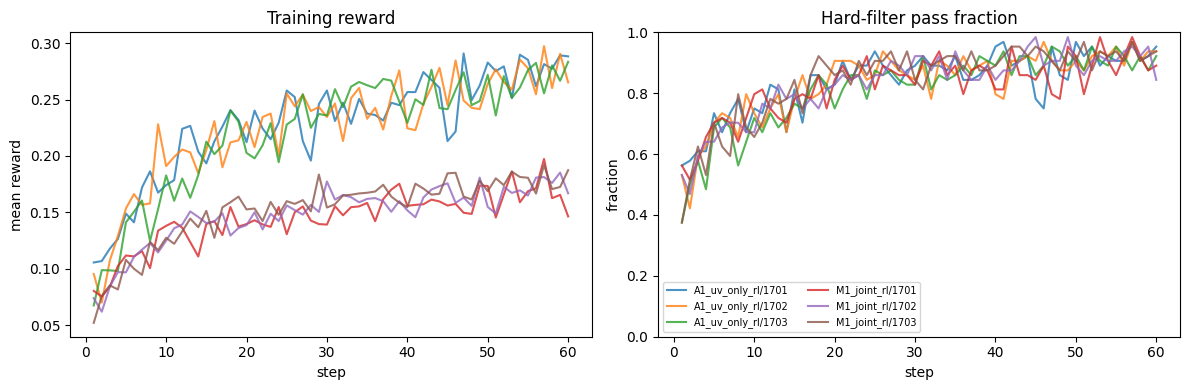

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (method, seed), part in rl_history.groupby(["method_id", "seed"]):
    axes[0].plot(part["step"], part["mean_reward"], alpha=0.8, label=f"{method}/{seed}")
    axes[1].plot(part["step"], part["hard_filter_fraction"], alpha=0.8, label=f"{method}/{seed}")
axes[0].set(title="Training reward", xlabel="step", ylabel="mean reward")
axes[1].set(title="Hard-filter pass fraction", xlabel="step", ylabel="fraction", ylim=(0, 1))
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 11. Fixed final proposal quotas and independent evaluation

Все 1200 final proposals каждого method/seed сохраняются в audit, включая invalid, duplicates,
known molecules и hard-filter failures. `generated.csv` содержит без cherry-picking все уникальные
внутри method/seed valid + novel + hard-filter-passing structures. Независимые ExtraTrees
evaluators применяются только после завершения генерации.

In [15]:
def sample_fixed_final(model, method_id, seed, objective):
    seed_everything(seed + 100_000)
    parts, remaining, batch_id = [], CFG.final_proposals_per_seed, 0
    while remaining:
        count = min(CFG.sample_batch_size, remaining)
        smiles, _ = sample_token_sequences(model, count, CFG.sampling_temperature)
        scored = score_reward_batch(smiles, objective)
        batch_id += 1
        scored["method_id"], scored["seed"], scored["phase"], scored["step"] = method_id, seed, "final", batch_id
        parts.append(scored)
        remaining -= count
    return pd.concat(parts, ignore_index=True)


final_parts = []
for run_seed in RUN_SEEDS:
    final_parts.append(sample_fixed_final(prior, "B0_prior_random", run_seed, "joint"))
    final_parts.append(sample_fixed_final(agents[("M1_joint_rl", run_seed)], "M1_joint_rl", run_seed, "joint"))
    final_parts.append(sample_fixed_final(agents[("A1_uv_only_rl", run_seed)], "A1_uv_only_rl", run_seed, "uv_only"))
final_audit = pd.concat(final_parts, ignore_index=True)
assert final_audit.groupby(["method_id", "seed"]).size().eq(CFG.final_proposals_per_seed).all()

full_audit = pd.concat([optimization_audit, final_audit], ignore_index=True)
full_audit.to_csv(OUTPUT_DIR / "full_proposal_audit.csv", index=False)
budget_counts = full_audit.groupby(["method_id", "seed"]).size()
assert budget_counts.eq(TOTAL_EVALUATION_BUDGET).all()
budget_ledger = budget_counts.rename("candidate_reward_evaluations").reset_index()
budget_ledger["optimization_evaluations"] = OPTIMIZATION_BUDGET
budget_ledger["final_evaluations"] = CFG.final_proposals_per_seed
budget_ledger.to_csv(OUTPUT_DIR / "budget_ledger.csv", index=False)
display(budget_ledger)

,method_id,seed,candidate_reward_evaluations,optimization_evaluations,final_evaluations
0,A1_uv_only_rl,1701,5040,3840,1200
1,A1_uv_only_rl,1702,5040,3840,1200
2,A1_uv_only_rl,1703,5040,3840,1200
3,B0_prior_random,1701,5040,3840,1200
4,B0_prior_random,1702,5040,3840,1200
5,B0_prior_random,1703,5040,3840,1200
6,M1_joint_rl,1701,5040,3840,1200
7,M1_joint_rl,1702,5040,3840,1200
8,M1_joint_rl,1703,5040,3840,1200


In [16]:
generated = final_audit[
    final_audit["rdkit_valid"]
    & final_audit["passes_hard_filters"]
    & final_audit["novel_vs_D_A_D_B"]
].copy()
generated = generated.drop_duplicates(["method_id", "seed", "canonical_smiles"]).reset_index(drop=True)
assert not generated.duplicated(["method_id", "seed", "canonical_smiles"]).any()

matrix = fingerprint_matrix(generated["canonical_smiles"].tolist())
eval_a, eval_unc_a = bundle_predict(evaluator_A, matrix)
eval_b, eval_unc_b = bundle_predict(evaluator_B, matrix)
generated["evaluator_pred_A_log10_half_life_h"] = eval_a
generated["evaluator_uncertainty_A_log10_h"] = eval_unc_a
generated["evaluator_pred_A_half_life_h"] = np.power(10.0, eval_a)
generated["evaluator_pred_B_lambda_max_nm"] = eval_b
generated["evaluator_uncertainty_B_nm"] = eval_unc_b

exact_distance_a, exact_distance_b = [], []
train_distance_a, train_distance_b = [], []
for canonical in generated["canonical_smiles"]:
    fp = bit_fingerprint(canonical)
    exact_distance_a.append(1.0 - max(DataStructs.BulkTanimotoSimilarity(fp, ALL_A_FPS), default=0.0))
    exact_distance_b.append(1.0 - max(DataStructs.BulkTanimotoSimilarity(fp, ALL_B_FPS), default=0.0))
    train_distance_a.append(1.0 - max(DataStructs.BulkTanimotoSimilarity(fp, A_REWARD_REFERENCE_FPS), default=0.0))
    train_distance_b.append(1.0 - max(DataStructs.BulkTanimotoSimilarity(fp, B_TRAIN_FULL_FPS), default=0.0))
generated["distance_to_D_A"] = exact_distance_a
generated["distance_to_D_B"] = exact_distance_b
generated["distance_to_D_A_train"] = train_distance_a
generated["distance_to_D_B_train"] = train_distance_b
generated["novelty"] = True
generated["ad_A_pass"] = generated["distance_to_D_A_train"] <= 1.0 - CFG.ad_a_threshold
generated["ad_B_pass"] = generated["distance_to_D_B_train"] <= 1.0 - CFG.ad_b_threshold
generated["evaluator_mean_A_status"] = generated["evaluator_pred_A_log10_half_life_h"].between(A_LOW, A_HIGH)
generated["evaluator_mean_B_status"] = generated["evaluator_pred_B_lambda_max_nm"].between(
    CFG.b_lambda_low_nm, CFG.b_lambda_high_nm
)
generated["evaluator_mean_joint_status"] = (
    generated["evaluator_mean_A_status"]
    & generated["evaluator_mean_B_status"]
    & generated["ad_A_pass"]
    & generated["ad_B_pass"]
)
generated["evaluator_conservative_A_status"] = (
    (generated["evaluator_pred_A_log10_half_life_h"] - evaluator_A["q90"] >= A_LOW)
    & (generated["evaluator_pred_A_log10_half_life_h"] + evaluator_A["q90"] <= A_HIGH)
)
generated["evaluator_conservative_B_status"] = (
    (generated["evaluator_pred_B_lambda_max_nm"] - evaluator_B["q90"] >= CFG.b_lambda_low_nm)
    & (generated["evaluator_pred_B_lambda_max_nm"] + evaluator_B["q90"] <= CFG.b_lambda_high_nm)
)
generated["evaluator_conservative_joint_status"] = (
    generated["evaluator_conservative_A_status"]
    & generated["evaluator_conservative_B_status"]
    & generated["ad_A_pass"]
    & generated["ad_B_pass"]
)
generated["smiles"] = generated["canonical_smiles"]
generated["reward_joint"] = generated["reward"]
generated["reward_conformal_q90_A_log10_h"] = reward_A["q90"]
generated["reward_conformal_q90_B_nm"] = reward_B["q90"]
generated["evaluator_conformal_q90_A_log10_h"] = evaluator_A["q90"]
generated["evaluator_conformal_q90_B_nm"] = evaluator_B["q90"]
generated["psoralen_alert"] = False
generated["structural_alert"] = False
generated["joint_success"] = generated["evaluator_mean_joint_status"]
generated["final_status"] = np.select(
    [
        ~generated["ad_A_pass"],
        ~generated["ad_B_pass"],
        ~generated["evaluator_mean_A_status"],
        ~generated["evaluator_mean_B_status"],
    ],
    ["FAIL_AD_A", "FAIL_AD_B", "FAIL_A", "FAIL_B"],
    default="PASS_JOINT",
)

export_columns = [
    "smiles", "canonical_smiles", "method_id", "seed", "rdkit_valid", "passes_hard_filters", "filter_reason",
    "novelty", "reward", "reward_joint", "reward_pred_A_log10_half_life_h", "reward_uncertainty_A_log10_h",
    "reward_conformal_q90_A_log10_h",
    "reward_pred_B_lambda_max_nm", "reward_uncertainty_B_nm",
    "reward_conformal_q90_B_nm",
    "evaluator_pred_A_log10_half_life_h", "evaluator_pred_A_half_life_h",
    "evaluator_uncertainty_A_log10_h", "evaluator_conformal_q90_A_log10_h",
    "evaluator_pred_B_lambda_max_nm", "evaluator_uncertainty_B_nm", "evaluator_conformal_q90_B_nm",
    "sa_score", "qed", "molecular_weight", "rotatable_bonds", "psoralen_similarity",
    "distance_to_D_A", "distance_to_D_B", "distance_to_D_A_train", "distance_to_D_B_train",
    "ad_A_pass", "ad_B_pass", "psoralen_alert", "structural_alert",
    "evaluator_mean_A_status", "evaluator_mean_B_status",
    "evaluator_mean_joint_status", "evaluator_conservative_A_status", "evaluator_conservative_B_status",
    "evaluator_conservative_joint_status", "joint_success", "final_status",
]
GENERATED_PATH = ROOT / "generated.csv"
generated[export_columns].to_csv(GENERATED_PATH, index=False)
assert len(generated) >= 1000, f"Only {len(generated)} valid novel molecules; fixed run failed acceptance criterion"
print(f"generated.csv rows={len(generated):,}")
display(generated[export_columns].head(20))

generated.csv rows=8,225


,smiles,canonical_smiles,method_id,seed,rdkit_valid,passes_hard_filters,filter_reason,novelty,reward,reward_joint,...,psoralen_alert,structural_alert,evaluator_mean_A_status,evaluator_mean_B_status,evaluator_mean_joint_status,evaluator_conservative_A_status,evaluator_conservative_B_status,evaluator_conservative_joint_status,joint_success,final_status
0,CCCCC=CSC(C)=CCc1ccc(O)cc1C,CCCCC=CSC(C)=CCc1ccc(O)cc1C,B0_prior_random,1701,True,True,ok,True,0.194467,0.194467,...,False,False,True,True,False,False,False,False,False,FAIL_AD_A
1,Cc1ccc2c(c3c(C#N)c4c(cc5cc(N(C)C)ccc5n1C=CC=CC...,Cc1ccc2c(c3c(C#N)c4c(cc5cc(N(C)C)ccc5n1C=CC=CC...,B0_prior_random,1701,True,True,ok,True,0.128573,0.128573,...,False,False,True,False,False,False,False,False,False,FAIL_AD_A
2,Cc1cc(F)ccc1CC=CC=CC1=c2ccccc2=CNC1,Cc1cc(F)ccc1CC=CC=CC1=c2ccccc2=CNC1,B0_prior_random,1701,True,True,ok,True,0.176674,0.176674,...,False,False,True,False,False,False,False,False,False,FAIL_AD_A
3,C=CC=C1C=c2ccc(=CC=CF)cc21,C=CC=C1C=c2ccc(=CC=CF)cc21,B0_prior_random,1701,True,True,ok,True,0.116797,0.116797,...,False,False,False,False,False,False,False,False,False,FAIL_AD_A
4,CCC=CC=CC=CC=O,CCC=CC=CC=CC=O,B0_prior_random,1701,True,True,ok,True,0.168454,0.168454,...,False,False,True,True,False,False,False,False,False,FAIL_AD_A
5,N#C/C(=C\C(N)=CI)C(=O)OSC=CC=C(Br)Cc1ccccc1,N#C/C(=C\C(N)=CI)C(=O)OSC=CC=C(Br)Cc1ccccc1,B0_prior_random,1701,True,True,ok,True,0.135714,0.135714,...,False,False,True,False,False,False,False,False,False,FAIL_AD_A
6,COC=CC1=CC(C#N)C=C1C=CC1=Cc2ccccc2C(O)c2cc(C)c...,COC=CC1=CC(C#N)C=C1C=CC1=Cc2ccccc2C(O)c2cc(C)c...,B0_prior_random,1701,True,True,ok,True,0.170285,0.170285,...,False,False,True,False,False,False,False,False,False,FAIL_AD_A
7,C=C1N=C(C)C2(CCCNN=CC)CCCCC2=CN=CS1,C=C1N=C(C)C2(CCCNN=CC)CCCCC2=CN=CS1,B0_prior_random,1701,True,True,ok,True,0.140220,0.140220,...,False,False,True,False,False,False,False,False,False,FAIL_AD_A
8,Cc1[nH]nc2c1/N=N/c1cccnc1C=CC2,Cc1[nH]nc2c1/N=N/c1cccnc1C=CC2,B0_prior_random,1701,True,True,ok,True,0.174615,0.174615,...,False,False,False,True,False,False,False,False,False,FAIL_A
9,CCCCNC=CC=C1C=Cc2cc(O)cc(c2N=Cc2ccccc2)C=C(c2c...,CCCCNC=CC=C1C=Cc2cc(O)cc(c2N=Cc2ccccc2)C=C(c2c...,B0_prior_random,1701,True,True,ok,True,0.113692,0.113692,...,False,False,True,False,False,False,False,False,False,FAIL_AD_A


## 12. Assignment metrics and ablation table

Validity/uniqueness/novelty считаются по фиксированной final quota. Primary JSR использует
фиксированный raw denominator, поэтому invalid, duplicate, filtered и OOD proposals считаются
неуспехами; дополнительный JSR по exported cohort приводится отдельно. Internal diversity — среднее `1−Tanimoto` по детерминированной
подвыборке не более 400 молекул. `AD_fraction` означает близость хотя бы к одному объекту полного
соответствующего dataset выше заданного threshold.

In [17]:
def internal_diversity(smiles_values, seed):
    unique = sorted(set(smiles_values))
    if len(unique) < 2:
        return np.nan
    rng = np.random.default_rng(seed)
    if len(unique) > 400:
        unique = [unique[i] for i in sorted(rng.choice(len(unique), 400, replace=False))]
    fps = [bit_fingerprint(s) for s in unique]
    distances = []
    for i in range(1, len(fps)):
        distances.extend(1.0 - np.asarray(DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])))
    return float(np.mean(distances))


metric_rows = []
for (method, seed), audit_part in final_audit.groupby(["method_id", "seed"]):
    valid = audit_part[audit_part["rdkit_valid"]]
    valid_canonical = valid["canonical_smiles"].dropna()
    unique_valid = pd.Index(valid_canonical.unique())
    output_part = generated[(generated["method_id"] == method) & (generated["seed"] == seed)]
    mean_successes = int(output_part["evaluator_mean_joint_status"].sum())
    conservative_successes = int(output_part["evaluator_conservative_joint_status"].sum())
    metric_rows.append({
        "method_id": method, "seed": int(seed),
        "candidate_reward_evaluations": TOTAL_EVALUATION_BUDGET,
        "final_proposal_count": len(audit_part),
        "validity": float(audit_part["rdkit_valid"].mean()),
        "hard_filter_pass_rate": float(audit_part["passes_hard_filters"].mean()),
        "uniqueness": float(valid_canonical.nunique() / max(len(valid_canonical), 1)),
        "novelty": float(np.mean([s not in KNOWN_UNION for s in unique_valid])) if len(unique_valid) else 0.0,
        "exported_valid_novel_unique": len(output_part),
        "evaluator_mean_JSR_raw": float(mean_successes / len(audit_part)),
        "evaluator_mean_JSR_exported": float(output_part["evaluator_mean_joint_status"].mean()) if len(output_part) else 0.0,
        "evaluator_conservative_JSR_raw": float(conservative_successes / len(audit_part)),
        "evaluator_conservative_JSR_exported": float(output_part["evaluator_conservative_joint_status"].mean()) if len(output_part) else 0.0,
        "internal_diversity": internal_diversity(output_part["canonical_smiles"], int(seed)),
        "mean_SA": float(output_part["sa_score"].mean()) if len(output_part) else np.nan,
        "median_SA": float(output_part["sa_score"].median()) if len(output_part) else np.nan,
        "q90_SA": float(output_part["sa_score"].quantile(0.90)) if len(output_part) else np.nan,
        "AD_A_fraction": float(output_part["ad_A_pass"].mean()) if len(output_part) else 0.0,
        "AD_B_fraction": float(output_part["ad_B_pass"].mean()) if len(output_part) else 0.0,
        "psoralen_rejection_rate": float(audit_part["filter_reason"].astype(str).str.contains("psoralen|angelicin").mean()),
        "structural_alert_rejection_rate": float(audit_part["filter_reason"].astype(str).str.startswith("structural_alert").mean()),
    })

strategy_metrics = pd.DataFrame(metric_rows).sort_values(["method_id", "seed"])
strategy_metrics.to_csv(OUTPUT_DIR / "strategy_metrics.csv", index=False)
ablation_table = strategy_metrics.groupby("method_id", as_index=False).agg(
    seeds=("seed", "nunique"), validity_mean=("validity", "mean"), uniqueness_mean=("uniqueness", "mean"),
    novelty_mean=("novelty", "mean"), evaluator_mean_JSR_raw_mean=("evaluator_mean_JSR_raw", "mean"),
    evaluator_mean_JSR_raw_std=("evaluator_mean_JSR_raw", "std"),
    evaluator_mean_JSR_exported_mean=("evaluator_mean_JSR_exported", "mean"),
    evaluator_conservative_JSR_raw_mean=("evaluator_conservative_JSR_raw", "mean"),
    internal_diversity_mean=("internal_diversity", "mean"), mean_SA=("mean_SA", "mean"),
    AD_A_fraction_mean=("AD_A_fraction", "mean"), AD_B_fraction_mean=("AD_B_fraction", "mean"),
)
ablation_table.to_csv(OUTPUT_DIR / "ablation_table.csv", index=False)
display(strategy_metrics)
display(ablation_table)
summary_by_method = ablation_table.set_index("method_id")
hypothesis_result = {
    "predeclared": (
        "M1_joint_rl increases independent-evaluator raw JSR over B0_prior_random "
        "without more than a 10% relative loss of internal diversity"
    ),
    "jsr_improved": bool(
        summary_by_method.loc["M1_joint_rl", "evaluator_mean_JSR_raw_mean"]
        > summary_by_method.loc["B0_prior_random", "evaluator_mean_JSR_raw_mean"]
    ),
    "diversity_retained": bool(
        summary_by_method.loc["M1_joint_rl", "internal_diversity_mean"]
        >= 0.90 * summary_by_method.loc["B0_prior_random", "internal_diversity_mean"]
    ),
}
hypothesis_result["supported"] = bool(
    hypothesis_result["jsr_improved"] and hypothesis_result["diversity_retained"]
)
display(pd.Series(hypothesis_result))

,method_id,seed,candidate_reward_evaluations,final_proposal_count,validity,hard_filter_pass_rate,uniqueness,novelty,exported_valid_novel_unique,evaluator_mean_JSR_raw,...,evaluator_conservative_JSR_raw,evaluator_conservative_JSR_exported,internal_diversity,mean_SA,median_SA,q90_SA,AD_A_fraction,AD_B_fraction,psoralen_rejection_rate,structural_alert_rejection_rate
0,A1_uv_only_rl,1701,5040,1200,0.999167,0.910000,0.970809,0.989691,1055,0.050833,...,0.0,0.0,0.863595,3.082084,2.962483,4.467448,0.153555,0.977251,0.0,0.0
1,A1_uv_only_rl,1702,5040,1200,1.000000,0.918333,0.974167,0.994012,1070,0.070000,...,0.0,0.0,0.848759,3.032648,2.932288,4.217949,0.166355,0.988785,0.0,0.0
2,A1_uv_only_rl,1703,5040,1200,1.000000,0.908333,0.991667,0.994958,1082,0.074167,...,0.0,0.0,0.868770,3.165660,3.017631,4.561259,0.181146,0.975970,0.0,0.0
3,B0_prior_random,1701,5040,1200,0.999167,0.482500,0.974979,0.992301,579,0.004167,...,0.0,0.0,0.902012,4.411902,4.488237,5.583605,0.044905,0.678756,0.0,0.0
4,B0_prior_random,1702,5040,1200,1.000000,0.485000,0.976667,0.992321,582,0.005833,...,0.0,0.0,0.902502,4.375929,4.391098,5.670415,0.067010,0.723368,0.0,0.0
5,B0_prior_random,1703,5040,1200,0.998333,0.495833,0.973266,0.993991,595,0.007500,...,0.0,0.0,0.903618,4.416228,4.482467,5.623613,0.055462,0.702521,0.0,0.0
6,M1_joint_rl,1701,5040,1200,1.000000,0.920000,0.985833,0.997464,1087,0.061667,...,0.0,0.0,0.869504,3.396464,3.355212,4.860711,0.160994,0.968721,0.0,0.0
7,M1_joint_rl,1702,5040,1200,1.000000,0.929167,0.970785,0.993121,1077,0.038333,...,0.0,0.0,0.864584,3.330513,3.305945,4.777099,0.142061,0.964717,0.0,0.0
8,M1_joint_rl,1703,5040,1200,1.000000,0.924167,0.988314,0.994932,1098,0.070833,...,0.0,0.0,0.860132,3.180584,3.050726,4.617997,0.182149,0.979053,0.0,0.0


,method_id,seeds,validity_mean,uniqueness_mean,novelty_mean,evaluator_mean_JSR_raw_mean,evaluator_mean_JSR_raw_std,evaluator_mean_JSR_exported_mean,evaluator_conservative_JSR_raw_mean,internal_diversity_mean,mean_SA,AD_A_fraction_mean,AD_B_fraction_mean
0,A1_uv_only_rl,3,0.999722,0.978881,0.992887,0.065000,0.012444,0.072860,0.0,0.860375,3.093464,0.167019,0.980669
1,B0_prior_random,3,0.999167,0.974971,0.992871,0.005833,0.001667,0.011930,0.0,0.902711,4.401353,0.055793,0.701548
2,M1_joint_rl,3,1.000000,0.981644,0.995173,0.056944,0.016757,0.062734,0.0,0.864740,3.302520,0.161735,0.970830


predeclared           M1_joint_rl increases independent-evaluator ra...
jsr_improved                                                       True
diversity_retained                                                 True
supported                                                          True
dtype: object

## 13. Provenance manifest and mandatory assertions

Negative results остаются first-class outputs: нулевой conservative JSR или отсутствие улучшения
M1 не считается ошибкой pipeline. Ошибкой являются пересечение D_A/D_B, несопоставимые budgets,
повторные output structures внутри run либо менее 1000 итоговых строк.

In [18]:
def package_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return "not-installed"


try:
    git_revision = subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
    ).stdout.strip()
except Exception:
    git_revision = "unavailable"

assert set(D_A["canonical_smiles"]).isdisjoint(D_B["canonical_smiles"])
assert full_audit.groupby(["method_id", "seed"]).size().nunique() == 1
assert full_audit.groupby(["method_id", "seed"]).size().iloc[0] == TOTAL_EVALUATION_BUDGET
assert final_audit.groupby(["method_id", "seed"]).size().eq(CFG.final_proposals_per_seed).all()
assert not generated.duplicated(["method_id", "seed", "canonical_smiles"]).any()
assert len(generated) >= 1000
required_generated_columns = {
    "smiles", "canonical_smiles", "method_id", "seed",
    "reward_pred_A_log10_half_life_h", "reward_pred_B_lambda_max_nm",
    "evaluator_pred_A_log10_half_life_h", "evaluator_pred_B_lambda_max_nm",
    "evaluator_uncertainty_A_log10_h", "evaluator_uncertainty_B_nm",
    "sa_score", "novelty", "distance_to_D_A", "distance_to_D_B",
    "ad_A_pass", "ad_B_pass", "joint_success", "final_status",
}
assert required_generated_columns <= set(generated.columns)
assert generated["rdkit_valid"].all()
assert generated["novelty"].all()
assert (generated["psoralen_similarity"] < CFG.max_psoralen_similarity).all()
assert not generated["filter_reason"].astype(str).str.contains("psoralen|angelicin").any()

manifest = {
    "purpose": "joint de novo SELFIES-GRU generation for MOST half-life and UV lambda-max",
    "scope_warning": "ML prioritisation only; no proof of absorption strength, safety, MOST performance, or synthesis",
    "git_revision": git_revision,
    "base_seed": BASE_SEED,
    "run_seeds": list(RUN_SEEDS),
    "device": str(DEVICE),
    "platform": platform.platform(),
    "python": platform.python_version(),
    "packages": {
        "numpy": np.__version__, "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
        "rdkit": rdBase.rdkitVersion, "torch": torch.__version__, "selfies": package_version("selfies"),
    },
    "sources": {
        "M01_url": CFG.m01_url, "M01_path": str(m01_path), "UV_urls": list(CFG.uv_urls),
        "UV_paths": {name: str(path) for name, path in uv_paths.items()}, "sha256": SOURCE_HASHES,
    },
    "datasets": {
        "D_A_rows": len(D_A), "D_B_rows": len(D_B), "removed_overlap": len(raw_overlap),
        "intersection_after_removal": 0, "split_summary": split_summary.to_dict(orient="records"),
        "A_target": "log10(ln(2) / rate_s^-1 / 3600), target half-life 4-24 h",
        "B_target": "median experimental lambda_max, target 300-400 nm",
    },
    "models": {
        "reward": "independent RF ensembles A/B", "evaluator": "independent ExtraTrees ensembles A/B",
        "uncertainty": "max(ensemble std, validation split-conformal q90 / 1.645)",
        "prior_A_repeat_factor": A_REPEAT_FACTOR,
    },
    "config": asdict(CFG),
    "budgets": {
        "optimization_per_method_seed": OPTIMIZATION_BUDGET,
        "final_per_method_seed": CFG.final_proposals_per_seed,
        "total_reward_evaluations_per_method_seed": TOTAL_EVALUATION_BUDGET,
    },
    "artifacts": {
        "generated": str(GENERATED_PATH), "full_audit": str(OUTPUT_DIR / "full_proposal_audit.csv"),
        "dataset_A": str(OUTPUT_DIR / "dataset_A_curated.csv"),
        "dataset_B": str(OUTPUT_DIR / "dataset_B_curated.csv"),
        "budget_ledger": str(OUTPUT_DIR / "budget_ledger.csv"),
        "reviewer_metrics": str(OUTPUT_DIR / "reviewer_metrics.csv"),
        "strategy_metrics": str(OUTPUT_DIR / "strategy_metrics.csv"),
        "ablation_table": str(OUTPUT_DIR / "ablation_table.csv"), "models": str(MODEL_DIR),
    },
    "reviewer_metrics": reviewer_metrics.to_dict(orient="records"),
    "strategy_metrics": strategy_metrics.to_dict(orient="records"),
    "hypothesis": hypothesis_result,
}
with (OUTPUT_DIR / "run_manifest.json").open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2, ensure_ascii=False)
print(f"DONE: {GENERATED_PATH}")
print(f"manifest: {OUTPUT_DIR / 'run_manifest.json'}")

DONE: /home/sigmatau17/TEST/generated.csv
manifest: /home/sigmatau17/TEST/outputs/uv_most_joint/run_manifest.json


## Interpretation and failure modes

- **Reviewer extrapolation:** D_A очень мал; высокий reward вне AD_A может быть артефактом.
- **Disjoint labels:** у generated structures нет ground truth одновременно A и B. JSR — прогноз
  независимых models, не экспериментальная success rate.
- **Condition dependence:** solvent/temperature агрегированы; реальные $t_{1/2}$ и $\lambda_{max}$
  могут отличаться.
- **UV intensity:** Beer–Lambert, $\varepsilon(\lambda)$, concentration, film thickness, critical
  wavelength и SPF не вычисляются, потому что одного $\lambda_{max}$ для них недостаточно.
- **Safety/synthesis:** отсутствие PAINS/psoralen/reactive alerts и SA≤6 — только triage.
- **RL comparison:** M1 считается поддержанной только если улучшает evaluator JSR относительно B0
  при сопоставимых diversity, SA и validity во всех/большинстве seeds. Иначе гипотеза отклоняется.

Основные артефакты: корневой `generated.csv`, полный audit, reviewer/strategy metrics, ablation
table, model checkpoints, training histories и manifest в `outputs/uv_most_joint/`.